In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    f1_score, precision_score,
    recall_score, matthews_corrcoef,
)

from sklearn.metrics import confusion_matrix
from scipy.stats import bootstrap

In [ ]:
# conectar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Cargar resultados

In [ ]:
import hashlib

def make_sample_id(text):
    """
    Genera un identificador único a partir del texto.
    """
    return hashlib.md5(str(text).encode("utf-8")).hexdigest()

In [ ]:
def load_results(file_path, model_name, task):
    df = pd.read_csv(file_path)
    df = df.dropna(subset=["pred"])

    if task == "multi":
        true_col = "label_mc"
    else:
        true_col = "bs"

    df["sample_id"] = (
        df["user_id"].astype(str)
        + "_"
        + df["texto"].apply(make_sample_id)
    )

    return pd.DataFrame({
        "sample_id": df["sample_id"],  # ID único por muestra
        "user_id": df["user_id"],      # ID único por usuario (puede repertirse en multiclase)
        "model": model_name,
        "task": task,
        "y_true": df[true_col],
        "y_pred": df["pred"].astype(int)
    })

In [ ]:
base = "/content/drive/MyDrive/tfg/corpusMentalRiskES/resultados/"
tasks = ["anx", "dep", "ed", "multi"]

bert_models = [
    "distilbert-base-spanish-uncased",
    "roberta-large-bne",
    "mdeberta-v3-base",
    "longformer-base-4096"
]
open_source_llms = [
    "llama-3.1-8b",
    "gpt-oss-20b",
    "deepseek-chat"
]
proprietary_llms = [
    "gpt-5.2",
    "claude-sonnet-4-6",
    "gemini-3.1-pro-preview"
]

llm_models = open_source_llms + proprietary_llms
models = bert_models + llm_models

dfs = []

# Cargar resultados de cada tarea y modelo
for task in tasks:
  for model in models:
    results = load_results(base + f"{model}_{task}.csv", model, task)
    dfs.append(results)

# Combinarlos en un único DataFrame
data = pd.concat(dfs, ignore_index=True)

In [ ]:
data

,sample_id,user_id,model,task,y_true,y_pred
0,subject140_63a30fedf71784db260e4aadf10178ad,subject140,distilbert-base-spanish-uncased,anx,1,1
1,subject166_e4ee2bef716575bf70af4c53444e4763,subject166,distilbert-base-spanish-uncased,anx,1,1
2,subject372_2eee8f795c6c35a6124a4672821b0985,subject372,distilbert-base-spanish-uncased,anx,1,1
3,subject365_cb0c6b260873490f6ec285ae9ce6e22b,subject365,distilbert-base-spanish-uncased,anx,1,1
4,subject404_0f8b7f8e3324f5d0fdd1a61e981928be,subject404,distilbert-base-spanish-uncased,anx,0,1
...,...,...,...,...,...,...
17590,subject95_f066b3d104a54a82a73691d19f07cc72,subject95,gemini-3.1-pro-preview,multi,3,3
17591,subject96_8795d7bd914483bc6ff607c6d62f781e,subject96,gemini-3.1-pro-preview,multi,3,3
17592,subject97_444925a00acdfaf1d8770203b0a6c51c,subject97,gemini-3.1-pro-preview,multi,3,3
17593,subject98_7793620fdb004a4f4fe4fe1763fb52d9,subject98,gemini-3.1-pro-preview,multi,3,3


# 2. Tabla principal de métricas

Este bloque construye la tabla principal de resultados para cada tarea:
- Métricas generales de clasificación
- Intervalos de confianza bootstrap (95%)
- Block Rate (solo LLMs)
- TARa@5 (solo LLMs)

Es válido tanto para clasificación binaria como multiclase.


## 2.1. Métricas generales

In [ ]:
def compute_metrics(y_true, y_pred):
    """
    Calcula las métricas principales de evaluación.

    Se utiliza:
    - F1 macro: métrica principal (especialmente importante con desbalanceo)
    - Precision macro
    - Recall macro
    - MCC (Matthews Correlation Coefficient): métrica robusta para clasificación desbalanceada
    """
    metrics = {}

    metrics["f1_macro"] = f1_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["precision"] = precision_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["recall"] = recall_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["mcc"] = matthews_corrcoef(y_true, y_pred)

    return metrics

## 2.2. Intervalos de confianza bootstrap (95%)

In [ ]:
def bootstrap_ci(y_true, y_pred, n_bootstrap=1000):
    """
    Calcula el intervalo de confianza del 95% mediante BCa bootstrap
    (Bias-Corrected and Accelerated).
    Se calcula un BCa bootstrap independiente para cada métrica.
    """

    ci = {}

    # =========================================================
    # Definir una función por métrica
    # =========================================================

    metric_functions = {
        "f1_macro": lambda yt, yp: f1_score(
            yt,
            yp,
            average="macro",
            zero_division=0
        ),

        "precision": lambda yt, yp: precision_score(
            yt,
            yp,
            average="macro",
            zero_division=0
        ),

        "recall": lambda yt, yp: recall_score(
            yt,
            yp,
            average="macro",
            zero_division=0
        ),

        "mcc": lambda yt, yp: matthews_corrcoef(
            yt,
            yp
        )
    }

    # =========================================================
    # Calcular IC para cada métrica
    # =========================================================

    for metric_name, metric_fn in metric_functions.items():

        result = bootstrap(
            (y_true.values, y_pred.values),
            metric_fn,
            paired=True, # mismo remuestreo para y_true e y_pred
            vectorized=False,
            confidence_level=0.95,
            n_resamples=n_bootstrap,
            method="BCa",
            random_state=42
        )

        lower = result.confidence_interval.low
        upper = result.confidence_interval.high

        # Si BCa devuelve NaN → fallback percentile
        # Se aplica en casos donde las predicciones casi idénticas
        # y BCa lanza DegenerateDataWarning
        if np.isnan(lower) or np.isnan(upper):

            values = []

            for _ in range(n_bootstrap):
                idx = np.random.choice(len(y_true), len(y_true), replace=True)

                yt = y_true.iloc[idx]
                yp = y_pred.iloc[idx]

                values.append(metric_fn(yt, yp))

            lower = np.percentile(values, 2.5)
            upper = np.percentile(values, 97.5)

        ci[metric_name] = (lower, upper)

    return ci

## 2.3. Métricas específicas de LLMs

### 2.3.1. Block rate (solo LLMs)

In [ ]:
def compute_block_rate(file_path):
    """
    Calcula el porcentaje de respuestas bloqueadas o fallidas del modelo.
    Se mide como: pred == NaN. Solo se aplica a LLMs.
    """
    df = pd.read_csv(file_path)
    return df["pred"].isna().mean()

### 2.3.2. TARa@5

In [ ]:
def load_tara_df(model, task):
    """
    Carga los datos necesarios para calcular TARa@5.
    """

    # Dataset completo (predicción original) y renombrar columna "pred" a "pred_run1"
    df_full = pd.read_csv(base + f"{model}_{task}.csv")
    df_full = df_full[["user_id", "pred"]].rename(columns={"pred": "pred_run1"})

    # Subconjunto usado para TARa@5 (contiene "pred_run2", ..., "pred_run5")
    df_tara = pd.read_csv(base + f"{model}_{task}_tara5.csv")

    # Fusionar ambos por user_id para añadir pred_run1 a df_tara
    df_tara = df_tara.merge(df_full, on="user_id", how="left")

    return df_tara

In [ ]:
def compute_tara(df_tara):
    """
    Calcula TARa@5: Para cada ejemplo se comparan las 5 predicciones y se calcula
    el grado de acuerdo respecto a la moda. El resultado final es la media del
    agreement sobre todos los ejemplos.

    Las predicciones vacías (NaN) se consideran desacuerdo,
    ya que representan fallos de generación o bloqueo del modelo.

    Ejemplo:
    [1, 1, 1, NaN, 0]
    → moda = 1
    → agreement = 3/5 = 0.60
    """

    pred_cols = [
        "pred_run1",
        "pred_run2",
        "pred_run3",
        "pred_run4",
        "pred_run5"
    ]

    agreements = []

    for _, row in df_tara.iterrows():

        # Extraer siempre las 5 predicciones (incluyendo NaN)
        preds = row[pred_cols]

        # Si todas son NaN, no se puede calcular moda
        if preds.dropna().empty:
            continue

        # La moda se calcula solo sobre predicciones válidas
        majority_class = preds.dropna().mode()[0]

        # NaN cuenta como desacuerdo porque != majority_class
        agreement = (preds == majority_class).mean()

        agreements.append(agreement)

    return np.mean(agreements) if agreements else np.nan

In [ ]:
def bootstrap_tara(df_tara, n_bootstrap=200):
    """
    Calcula el intervalo de confianza del 95% para TARa@5
    mediante BCa bootstrap (Bias-Corrected and Accelerated).

    Cada remuestreo mantiene completas las 5 predicciones
    de cada ejemplo (pred_run1 ... pred_run5), preservando
    correctamente la estructura de TARa.
    """
    # =========================================================
    # Función estadística para bootstrap
    # =========================================================

    def tara_statistic(sample_indices):
        """
        Calcula TARa sobre una muestra bootstrap
        definida por sus índices.
        """
        sample = df_tara.iloc[sample_indices]
        return compute_tara(sample)

    # =========================================================
    # Índices base sobre los que scipy hará remuestreo
    # =========================================================

    indices = np.arange(len(df_tara))

    # =========================================================
    # BCa bootstrap
    # =========================================================
    result = bootstrap(
        (indices,),
        tara_statistic,
        vectorized=False,
        paired=False,
        confidence_level=0.95,
        n_resamples=n_bootstrap,
        method="BCa",
        random_state=42
    )

    lower = result.confidence_interval.low
    upper = result.confidence_interval.high

    return lower, upper

## 2.4. Construir tabla final con todas las métricas

In [ ]:
def metrics_with_ci(df, task):
    """
    Construye la tabla final de métricas para una tarea usando las funciones anteriores.
    """
    results = []

    # Iterar sobre cada modelo
    for model in df["model"].unique():
        subset = df[df["model"] == model]

        y_true = subset["y_true"]
        y_pred = subset["y_pred"]

        # Métricas generales
        base_metrics = compute_metrics(y_true, y_pred)

        # IC 95% BCa bootstrap
        ci = bootstrap_ci(y_true, y_pred)

        # Guardar cada métrica con su IC
        row = {"model": model}
        for metric in base_metrics:
            low, high = ci[metric]
            row[metric] = f"{base_metrics[metric]:.3f} [{low:.3f}, {high:.3f}]"

        # Block rate
        if model in llm_models:
            file_path = base + f"{model}_{task}.csv"
            block_rate = compute_block_rate(file_path)
            row["block_rate"] = f"{block_rate:.3f}"
        else:
            row["block_rate"] = "-"

        # TARA@5
        if model in llm_models:
            df_tara = load_tara_df(model, task)

            tara = compute_tara(df_tara)
            low, high = bootstrap_tara(df_tara)

            row["tara@5"] = f"{tara:.3f} [{low:.3f}, {high:.3f}]"
        else:
            row["tara@5"] = "-"

        results.append(row)

    return pd.DataFrame(results).set_index("model")

Ejecucion completa (por tarea)

In [ ]:
def display_table(task):
    df_task = data[data["task"] == task]

    # Tabla con IC
    table_ci = metrics_with_ci(df_task, task)

    display(table_ci)

    return table_ci

In [ ]:
metricas_anx = display_table("anx")

/usr/local/lib/python3.12/dist-packages/scipy/stats/_resampling.py:147: RuntimeWarning: invalid value encountered in scalar divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:352: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_resampling.py:147: RuntimeWarning: invalid value encountered in scalar divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:352: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


,f1_macro,precision,recall,mcc,block_rate,tara@5
model,,,,,,
distilbert-base-spanish-uncased,"0.650 [0.476, 0.823]","0.670 [0.458, 0.873]","0.636 [0.478, 0.835]","0.305 [-0.056, 0.644]",-,-
roberta-large-bne,"0.680 [0.529, 0.830]","0.660 [0.531, 0.811]","0.717 [0.527, 0.880]","0.373 [0.073, 0.658]",-,-
mdeberta-v3-base,"0.593 [0.460, 0.791]","0.616 [0.443, 0.897]","0.581 [0.470, 0.798]","0.194 [-0.079, 0.572]",-,-
longformer-base-4096,"0.468 [0.440, 0.486]","0.440 [0.393, 0.473]","0.500 [0.500, 0.500]","0.000 [0.000, 0.000]",-,-
llama-3.1-8b,"0.711 [0.642, 0.788]","0.856 [0.759, 0.927]","0.661 [0.604, 0.729]","0.479 [0.346, 0.613]",0.000,"0.980 [0.959, 0.992]"
gpt-oss-20b,"0.840 [0.780, 0.891]","0.932 [0.857, 0.965]","0.786 [0.726, 0.850]","0.703 [0.597, 0.794]",0.000,"0.988 [0.969, 0.996]"
deepseek-chat,"0.739 [0.677, 0.794]","0.713 [0.653, 0.769]","0.778 [0.714, 0.840]","0.487 [0.368, 0.595]",0.000,"0.988 [0.960, 0.996]"
gpt-5.2,"0.820 [0.757, 0.878]","0.915 [0.838, 0.957]","0.767 [0.701, 0.831]","0.666 [0.547, 0.766]",0.000,"0.998 [0.991, 1.000]"
claude-sonnet-4-6,"0.805 [0.732, 0.862]","0.909 [0.830, 0.951]","0.750 [0.679, 0.815]","0.640 [0.514, 0.740]",0.000,"0.994 [0.986, 0.998]"


In [ ]:
metricas_dep = display_table("dep")

/usr/local/lib/python3.12/dist-packages/scipy/stats/_resampling.py:147: RuntimeWarning: invalid value encountered in scalar divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:352: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_resampling.py:147: RuntimeWarning: invalid value encountered in scalar divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:352: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


,f1_macro,precision,recall,mcc,block_rate,tara@5
model,,,,,,
distilbert-base-spanish-uncased,"0.797 [0.692, 0.888]","0.790 [0.686, 0.889]","0.810 [0.697, 0.892]","0.600 [0.386, 0.774]",-,-
roberta-large-bne,"0.831 [0.728, 0.915]","0.825 [0.723, 0.906]","0.860 [0.753, 0.925]","0.684 [0.483, 0.828]",-,-
mdeberta-v3-base,"0.785 [0.670, 0.869]","0.778 [0.670, 0.864]","0.800 [0.680, 0.876]","0.577 [0.350, 0.736]",-,-
longformer-base-4096,"0.400 [0.359, 0.434]","0.333 [0.280, 0.384]","0.500 [0.500, 0.500]","0.000 [0.000, 0.000]",-,-
llama-3.1-8b,"0.801 [0.760, 0.837]","0.821 [0.777, 0.856]","0.789 [0.750, 0.829]","0.609 [0.526, 0.679]",0.002,"0.964 [0.936, 0.982]"
gpt-oss-20b,"0.811 [0.773, 0.848]","0.831 [0.793, 0.871]","0.798 [0.759, 0.836]","0.628 [0.553, 0.702]",0.000,"0.964 [0.929, 0.978]"
deepseek-chat,"0.855 [0.821, 0.884]","0.846 [0.811, 0.876]","0.880 [0.850, 0.905]","0.725 [0.665, 0.781]",0.000,"0.988 [0.964, 0.996]"
gpt-5.2,"0.847 [0.811, 0.878]","0.846 [0.811, 0.879]","0.848 [0.814, 0.881]","0.694 [0.624, 0.756]",0.000,"0.996 [0.977, 1.000]"
claude-sonnet-4-6,"0.824 [0.785, 0.861]","0.847 [0.808, 0.882]","0.810 [0.771, 0.848]","0.657 [0.580, 0.727]",0.000,"0.992 [0.976, 0.998]"


In [ ]:
metricas_ed = display_table("ed")

/usr/local/lib/python3.12/dist-packages/scipy/stats/_resampling.py:147: RuntimeWarning: invalid value encountered in scalar divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:352: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_resampling.py:147: RuntimeWarning: invalid value encountered in scalar divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:352: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


,f1_macro,precision,recall,mcc,block_rate,tara@5
model,,,,,,
distilbert-base-spanish-uncased,"0.920 [0.822, 0.980]","0.920 [0.814, 0.977]","0.920 [0.819, 0.978]","0.840 [0.629, 0.958]",-,-
roberta-large-bne,"0.940 [0.838, 0.980]","0.943 [0.859, 1.000]","0.937 [0.816, 0.983]","0.880 [0.669, 0.961]",-,-
mdeberta-v3-base,"0.816 [0.694, 0.915]","0.827 [0.696, 0.912]","0.812 [0.692, 0.912]","0.639 [0.385, 0.818]",-,-
longformer-base-4096,"0.362 [0.305, 0.407]","0.284 [0.220, 0.343]","0.500 [0.500, 0.500]","0.000 [0.000, 0.000]",-,-
llama-3.1-8b,"0.805 [0.760, 0.852]","0.824 [0.782, 0.870]","0.798 [0.754, 0.843]","0.622 [0.534, 0.707]",0.000,"0.952 [0.924, 0.970]"
gpt-oss-20b,"0.933 [0.901, 0.955]","0.934 [0.901, 0.956]","0.932 [0.900, 0.954]","0.866 [0.801, 0.909]",0.000,"0.952 [0.922, 0.972]"
deepseek-chat,"0.905 [0.869, 0.933]","0.909 [0.873, 0.936]","0.901 [0.866, 0.931]","0.811 [0.739, 0.866]",0.000,"0.996 [0.976, 1.000]"
gpt-5.2,"0.963 [0.942, 0.982]","0.963 [0.942, 0.981]","0.963 [0.942, 0.982]","0.927 [0.884, 0.963]",0.000,"0.992 [0.976, 0.996]"
claude-sonnet-4-6,"0.936 [0.907, 0.961]","0.934 [0.905, 0.959]","0.939 [0.909, 0.963]","0.873 [0.814, 0.921]",0.000,"0.996 [0.988, 1.000]"


In [ ]:
metricas_multi = display_table("multi")

,f1_macro,precision,recall,mcc,block_rate,tara@5
model,,,,,,
distilbert-base-spanish-uncased,"0.818 [0.758, 0.865]","0.844 [0.778, 0.884]","0.834 [0.775, 0.875]","0.744 [0.673, 0.807]",-,-
roberta-large-bne,"0.842 [0.778, 0.890]","0.846 [0.774, 0.895]","0.845 [0.780, 0.888]","0.786 [0.703, 0.846]",-,-
mdeberta-v3-base,"0.790 [0.725, 0.846]","0.822 [0.762, 0.867]","0.779 [0.705, 0.838]","0.709 [0.628, 0.779]",-,-
longformer-base-4096,"0.770 [0.706, 0.824]","0.778 [0.708, 0.833]","0.775 [0.705, 0.826]","0.674 [0.588, 0.747]",-,-
llama-3.1-8b,"0.729 [0.706, 0.752]","0.732 [0.710, 0.753]","0.783 [0.763, 0.801]","0.667 [0.638, 0.694]",0.001,"0.837 [0.822, 0.846]"
gpt-oss-20b,"0.787 [0.761, 0.810]","0.792 [0.766, 0.816]","0.799 [0.774, 0.820]","0.715 [0.683, 0.744]",0.000,"0.847 [0.837, 0.856]"
deepseek-chat,"0.802 [0.780, 0.822]","0.825 [0.801, 0.842]","0.801 [0.777, 0.821]","0.725 [0.697, 0.751]",0.000,"0.883 [0.877, 0.891]"
gpt-5.2,"0.789 [0.764, 0.810]","0.802 [0.779, 0.823]","0.819 [0.799, 0.835]","0.725 [0.696, 0.750]",0.000,"0.868 [0.860, 0.878]"
claude-sonnet-4-6,"0.785 [0.761, 0.806]","0.797 [0.776, 0.818]","0.827 [0.810, 0.844]","0.731 [0.705, 0.758]",0.000,"0.878 [0.872, 0.885]"


# 3. Matrices de Confusión

In [ ]:
def plot_confusion_matrices_grid(df, models, task, normalize=True, n_cols=3):
    """
    Genera una cuadrícula de matrices de confusión para todos los modelos
    evaluados en una tarea concreta.

    Puede aplicarse tanto a clasificación binaria como a multiclase

    Si normalize=True, cada fila se normaliza para mostrar proporciones
    en lugar de frecuencias absolutas.
    """

    # =========================================================
    # Definir etiquetas según el tipo de tarea
    # =========================================================
    if task == "multi":
        # Multiclase
        labels = [0, 1, 2, 3]
    else:
        # Binaria
        labels = [0, 1]

    # =========================================================
    # Configuración de la cuadrícula de gráficos
    # =========================================================
    n = len(models)
    cols = n_cols
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*4))
    axes = axes.flatten()

    # =========================================================
    # Generar matriz de confusión para cada modelo
    # =========================================================
    for i, model in enumerate(models):
        subset = df[
            (df["model"] == model) &
            (df["task"] == task)
        ]

        y_true = subset["y_true"]
        y_pred = subset["y_pred"]

        cm = confusion_matrix(y_true, y_pred, labels=labels)

        if normalize:
          cm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
          cm = cm * 100

        sns.heatmap(
            cm,
            annot = np.array([[f"{x:.1f}%" for x in row] for row in cm]),
            fmt="",
            cmap="Blues",
            xticklabels=labels,
            yticklabels=labels,
            ax=axes[i]
        )

        axes[i].set_title(model)
        axes[i].set_xlabel("Predicted")
        axes[i].set_ylabel("True")

    # eliminar subplots vacíos
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(f"Confusion Matrices - {task}", fontsize=16)
    plt.tight_layout()
    plt.show()

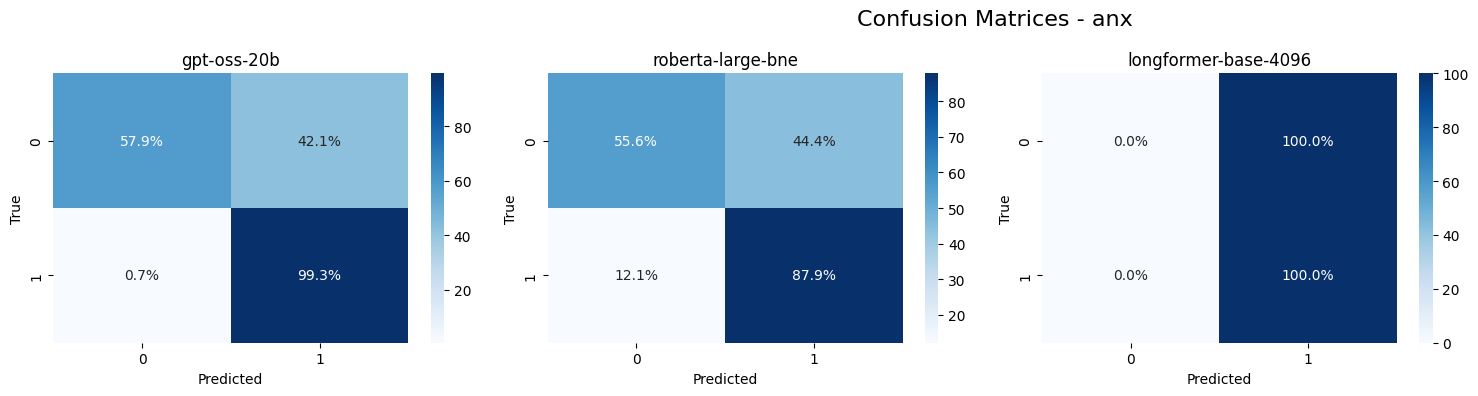

In [ ]:
models_anx = ["gpt-oss-20b", "roberta-large-bne", "longformer-base-4096"]
plot_confusion_matrices_grid(data, models_anx, "anx")

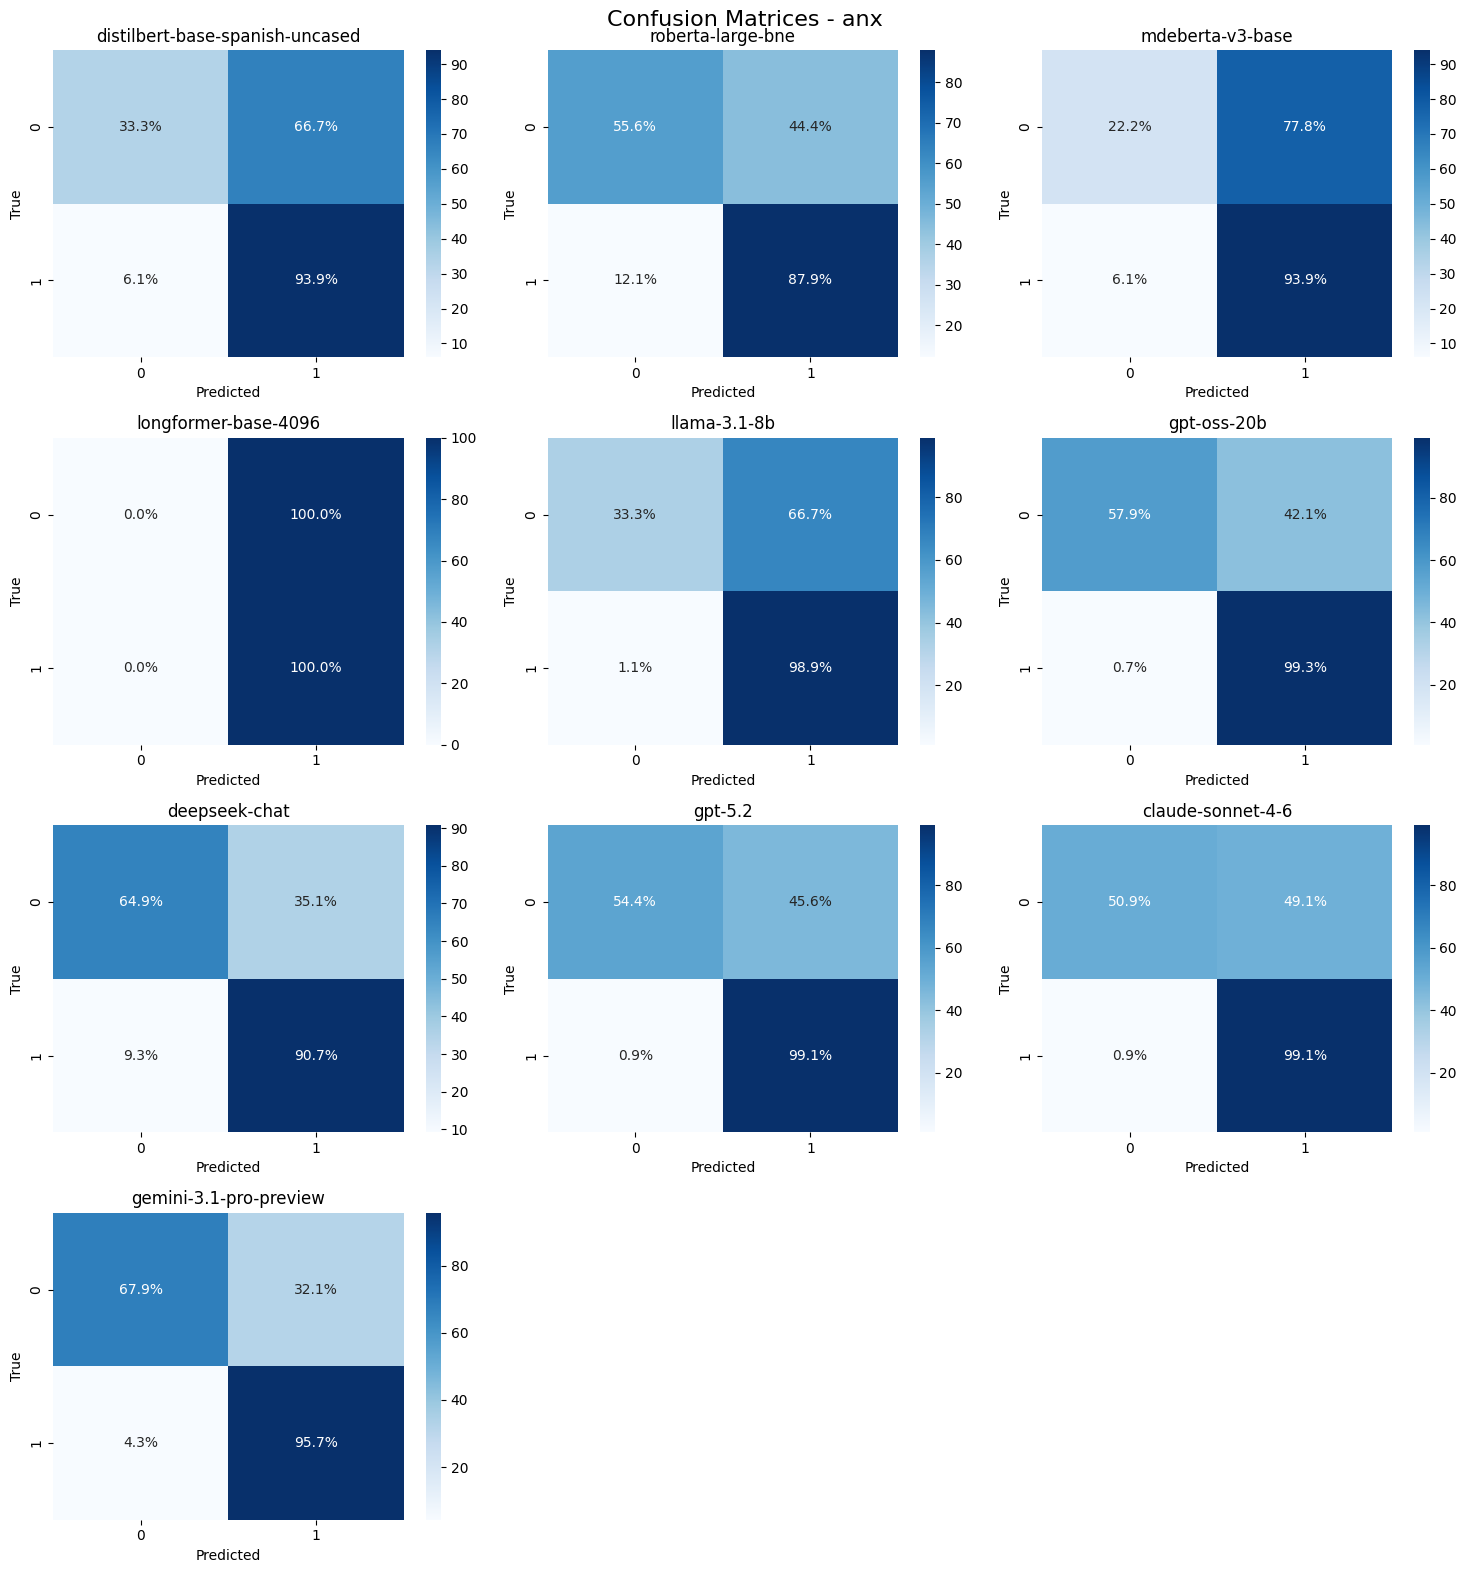

In [ ]:
plot_confusion_matrices_grid(data, models, "anx")

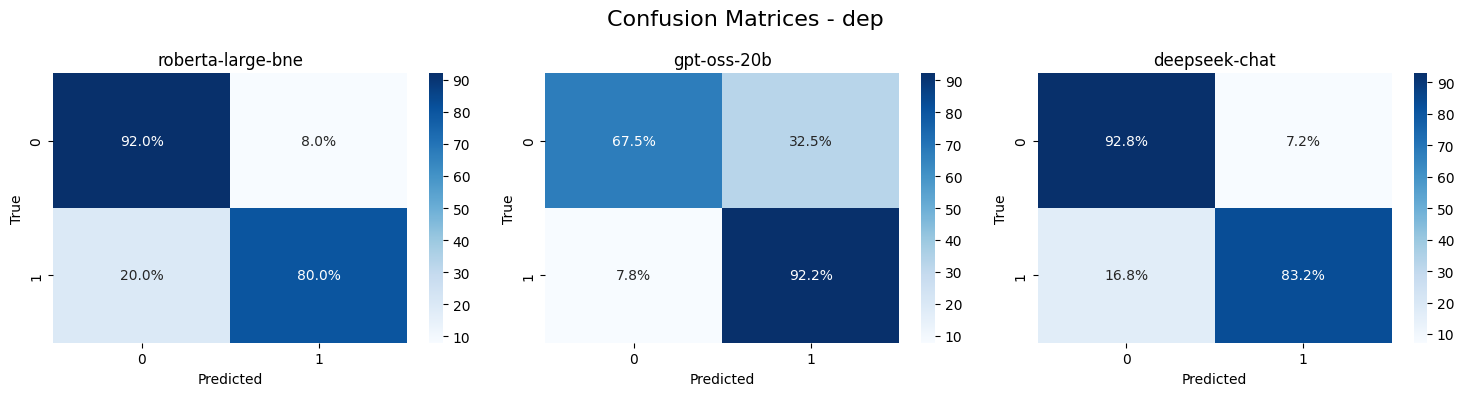

In [ ]:
models_dep = ["roberta-large-bne", "gpt-oss-20b", "deepseek-chat"]
plot_confusion_matrices_grid(data, models_dep, "dep")

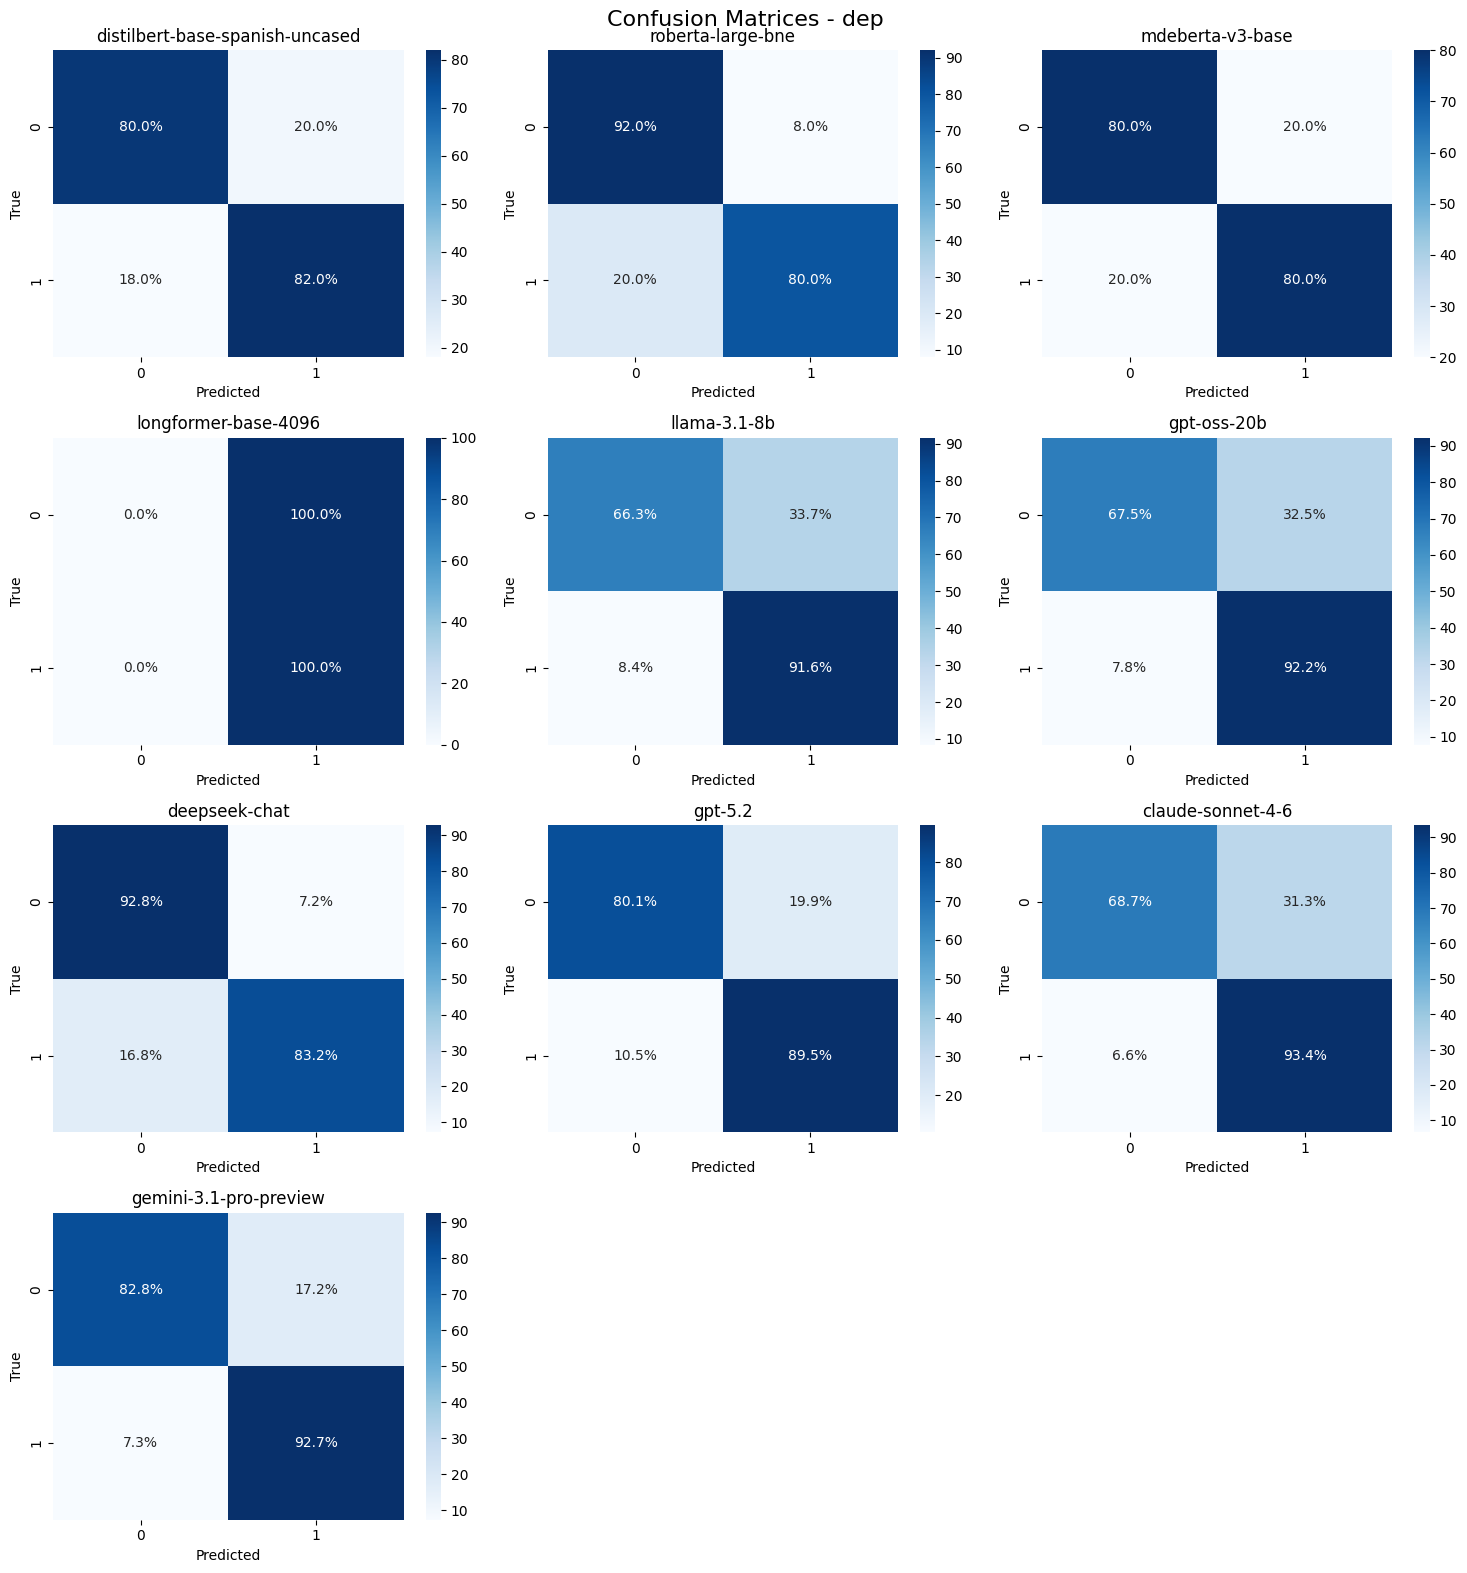

In [ ]:
plot_confusion_matrices_grid(data, models, "dep")

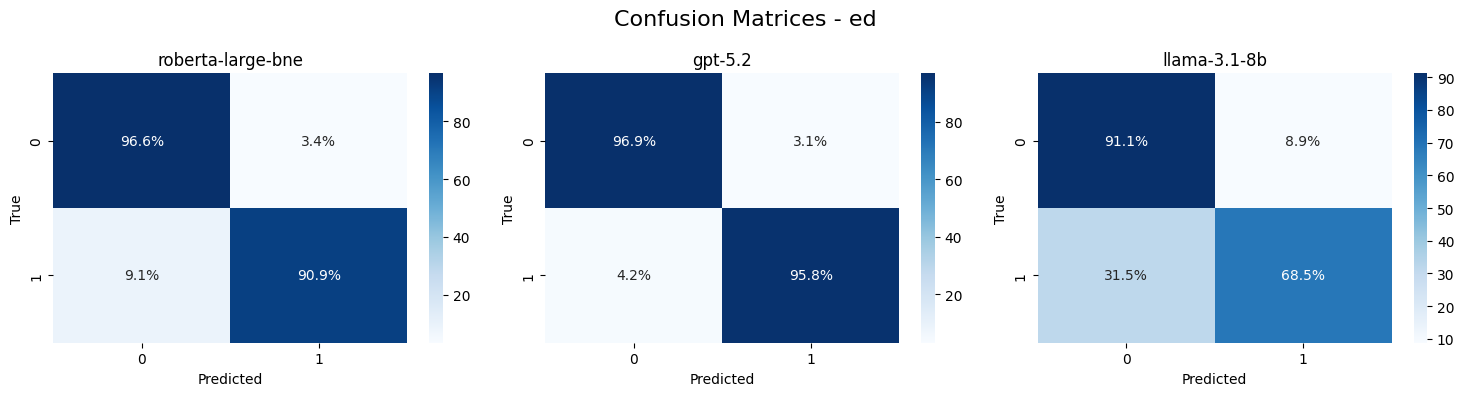

In [ ]:
models_ed = ["roberta-large-bne", "gpt-5.2", "llama-3.1-8b"]
plot_confusion_matrices_grid(data, models_ed, "ed", n_cols=3)

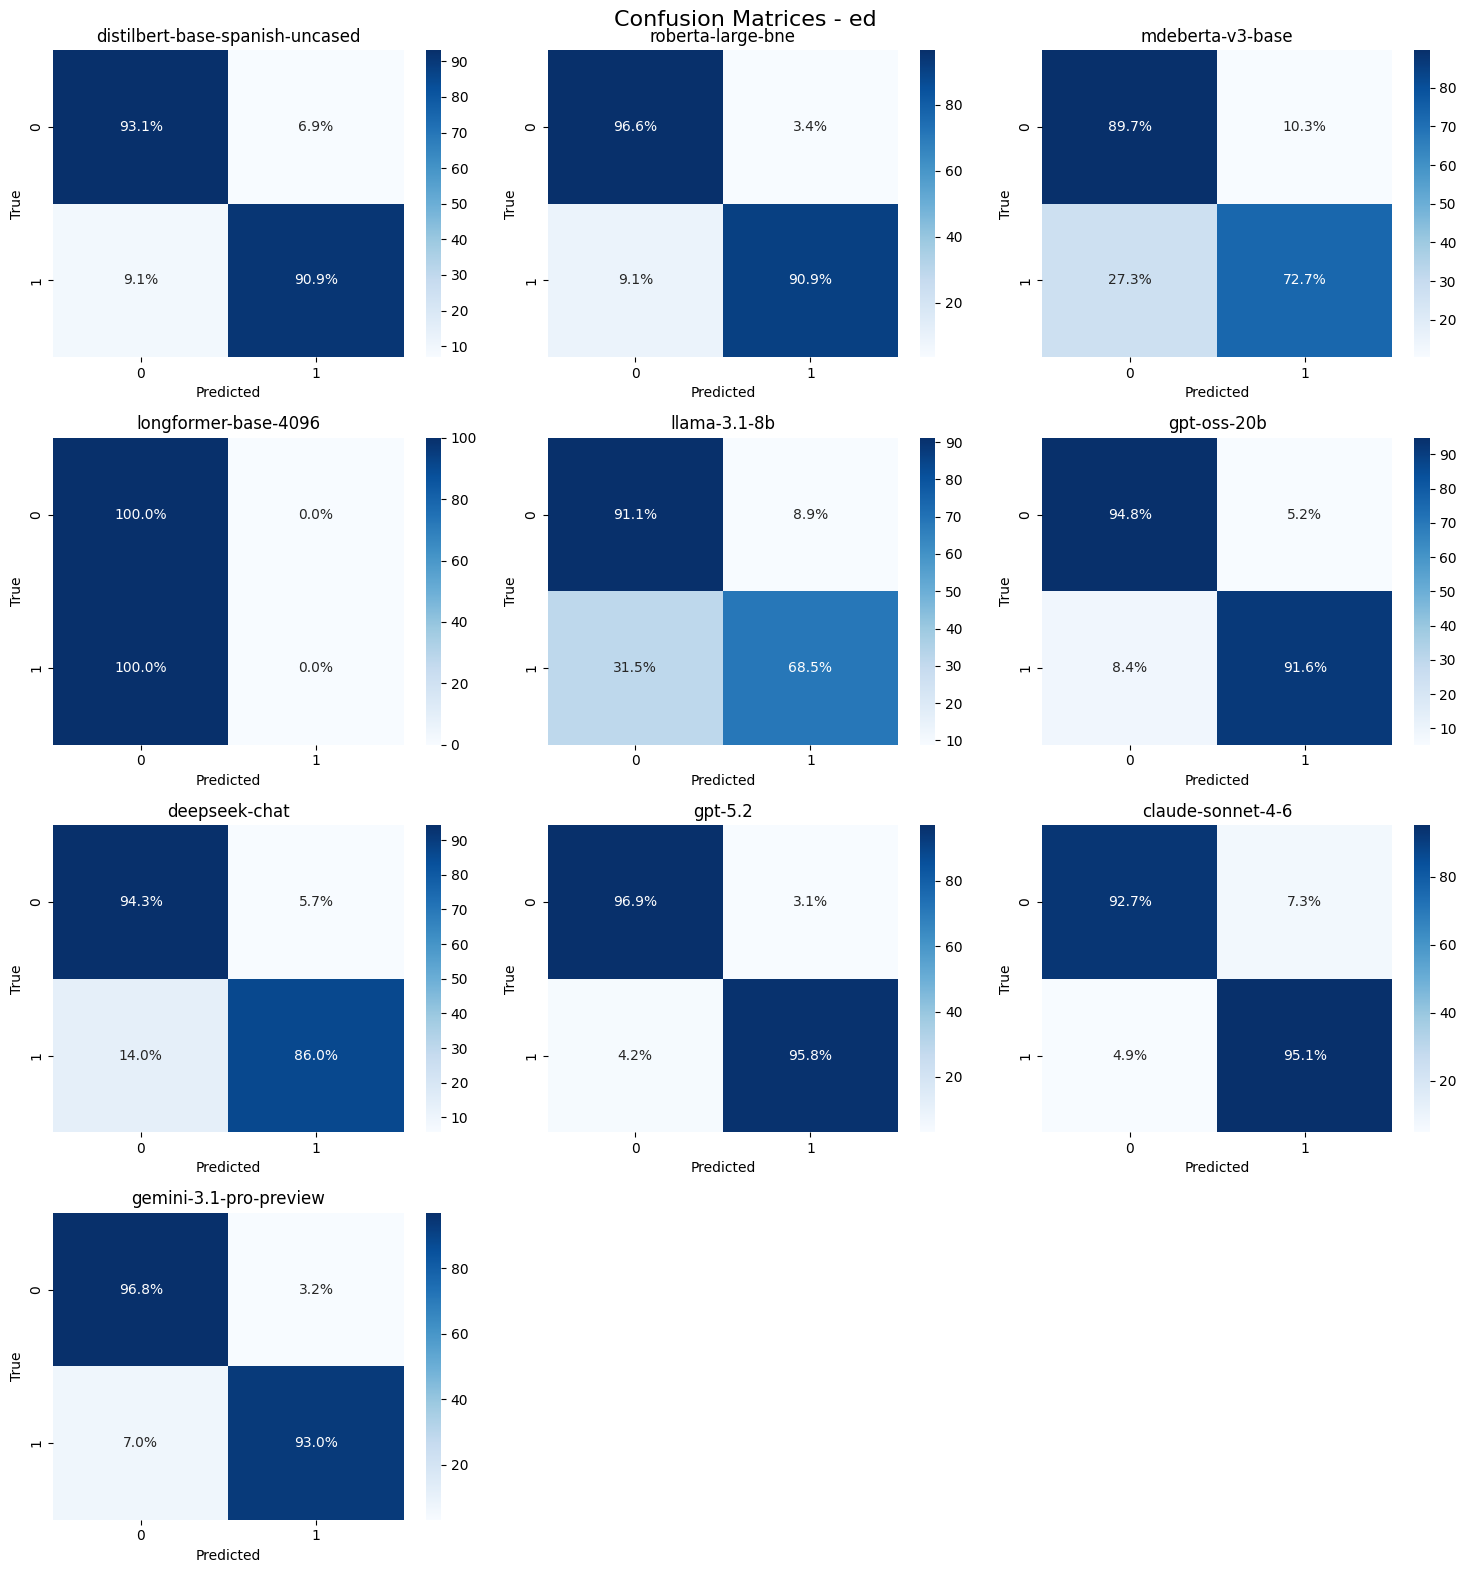

In [ ]:
plot_confusion_matrices_grid(data, models, "ed")

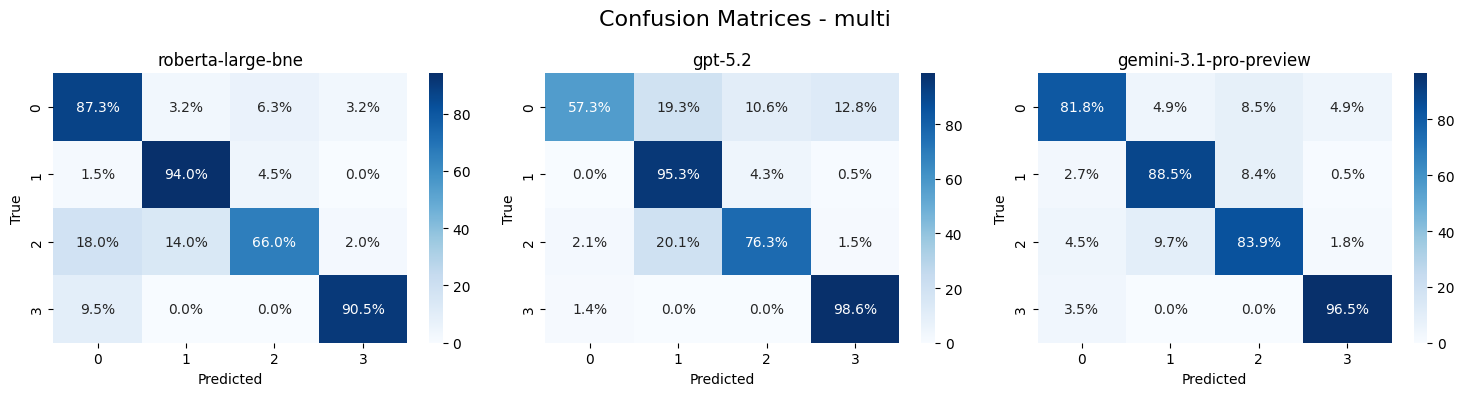

In [ ]:
models_multi = ["roberta-large-bne", "gpt-5.2", "gemini-3.1-pro-preview"]
plot_confusion_matrices_grid(data, models_multi, "multi")

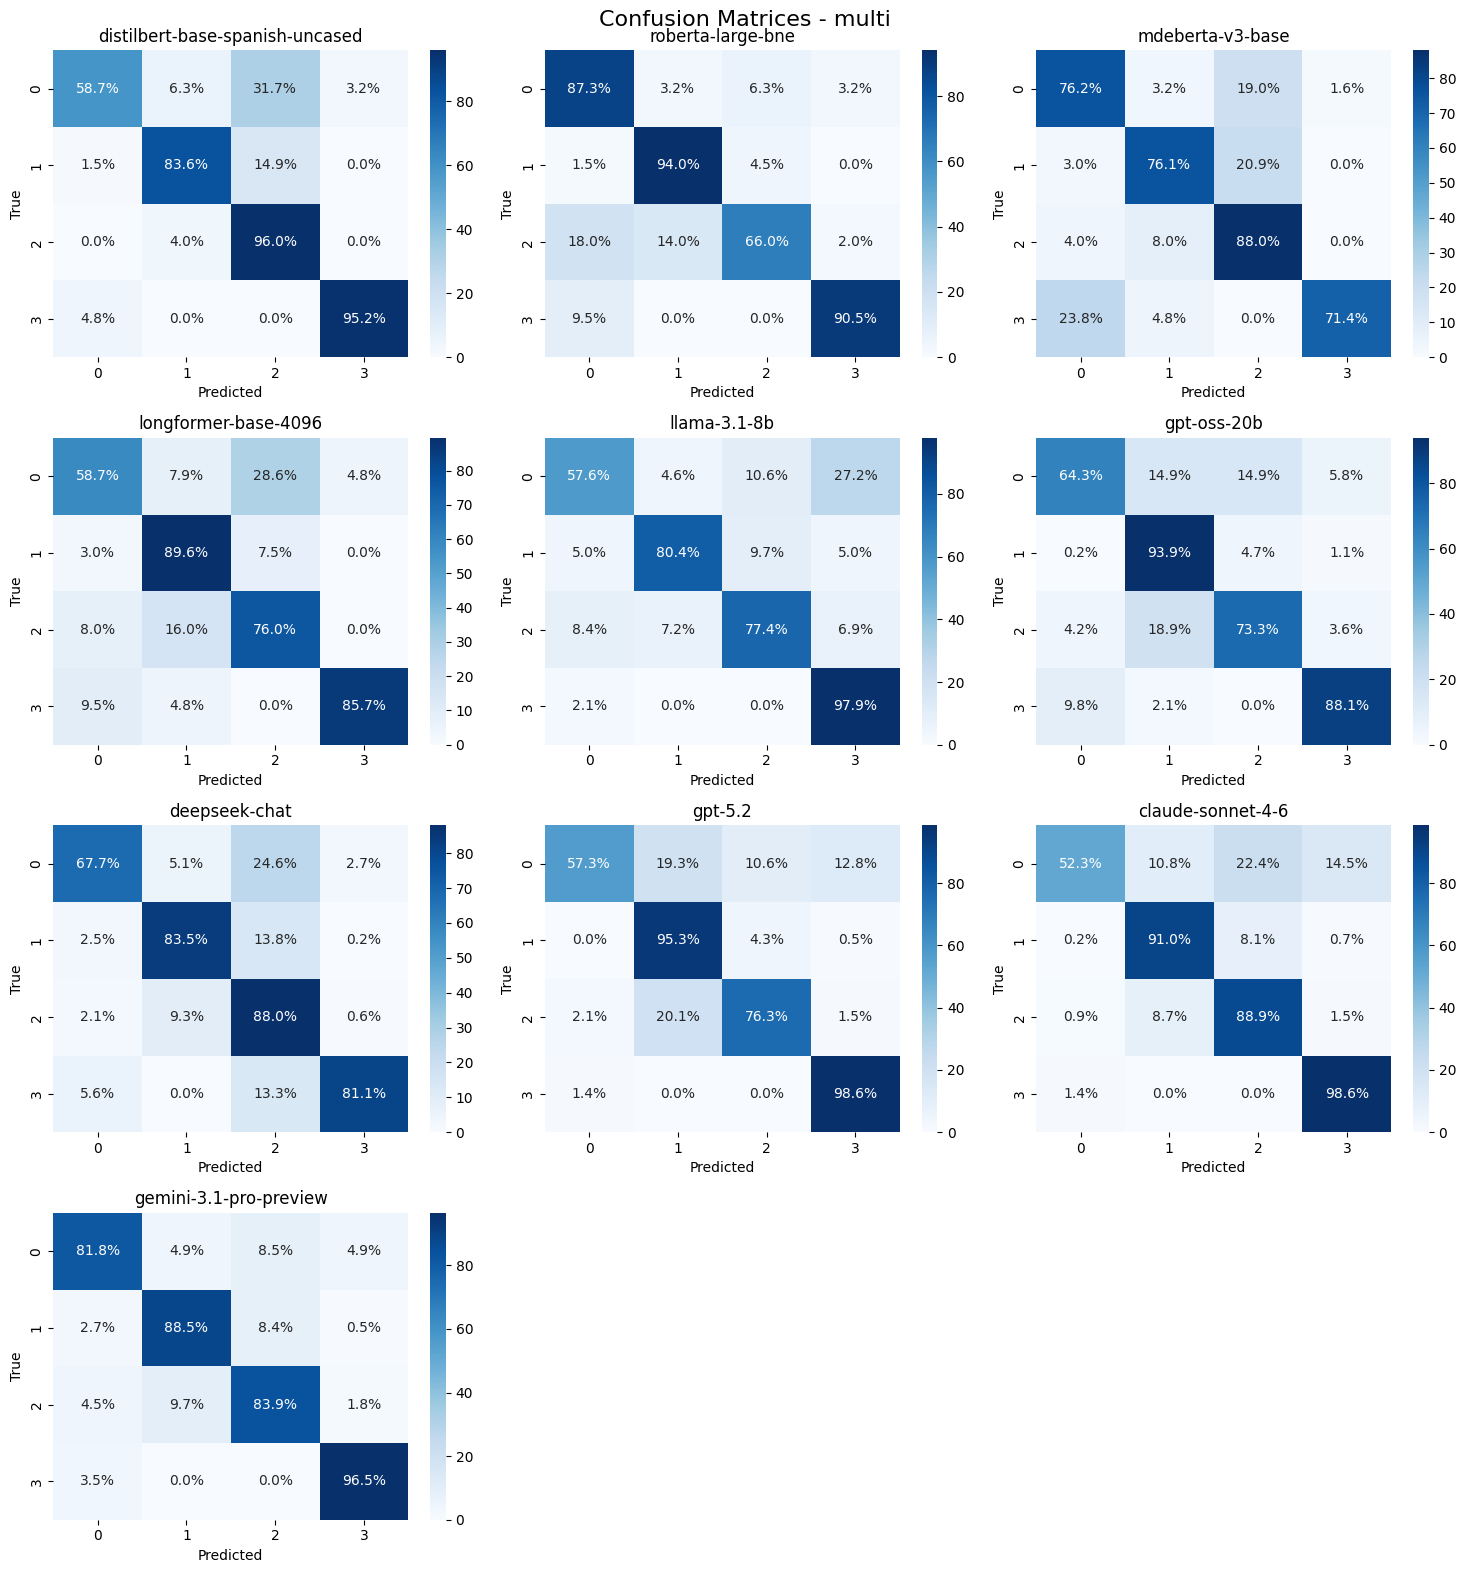

In [ ]:
plot_confusion_matrices_grid(data, models, "multi")

# 4. Bootstrap pareado (comparación entre modelos)

En este bloque se realiza la comparación estadística entre modelos mediante bootstrap pareado, utilizando F1 macro como métrica principal. El objetivo no es solo observar qué modelo obtiene mejor resultado, sino comprobar si esa diferencia de rendimiento es realmente significativa o puede deberse a la variabilidad de la muestra utilizada.

Para ello:
- Se seleccionan los modelos con mejor rendimiento según la tabla resumen de métricas.
- Se comparan todos los pares posibles entre esos modelos sobre exactamente los mismos ejemplos (user_id), garantizando una comparación justa.
- En cada comparación se aplica bootstrap pareado para estimar:
  - la diferencia media de F1 macro (Mean Δ)
  - el intervalo de confianza del 95%
  - el p-value bilateral asociado

El p-value indica la probabilidad de observar una diferencia igual o mayor entre dos modelos si en realidad ambos tuvieran un rendimiento equivalente. Un valor pequeño (habitualmente menor que 0.05) sugiere que la diferencia observada es estadísticamente significativa y, por tanto, poco probable que se explique únicamente por la variabilidad de la muestra.

Dado que se realizan múltiples comparaciones entre modelos, se aplica además la corrección Benjamini-Hochberg (BH), que ajusta los p-values para controlar el riesgo de falsos positivos. Esto evita considerar como significativas diferencias que podrían aparecer simplemente por realizar muchas pruebas estadísticas de forma simultánea.

Esto permite identificar qué mejoras entre modelos son realmente robustas y cuáles no presentan diferencias suficientemente significativas.

In [ ]:
def bootstrap_paired_test(y_true, y_pred_a, y_pred_b, metric_fn, n_bootstrap=1000):
    """
    Realiza bootstrap pareado entre dos modelos.

    En cada iteración:
    - se remuestrean los mismos ejemplos con reemplazo
    - se calcula la métrica para ambos modelos
    - se almacena la diferencia:
        metric(model_a) - metric(model_b)

    Esto permite estimar:
    - intervalo de confianza (95%) mediante BCa bootstrap
    - p-value bilateral
    - Cohen's d para muestras pareadas
    """

    # =========================================================
    # Función estadística para bootstrap
    # =========================================================

    def paired_difference(yt, ya, yb):
        """
        Calcula la diferencia de rendimiento entre dos modelos
        sobre una muestra bootstrap.
        """
        return metric_fn(yt, ya) - metric_fn(yt, yb)

    # =========================================================
    # BCa bootstrap directo sobre los datos originales
    # =========================================================

    result = bootstrap(
        (
            y_true.values,
            y_pred_a.values,
            y_pred_b.values
        ),
        paired_difference,
        paired=True,              # mismo remuestreo para los 3 arrays
        vectorized=False,
        confidence_level=0.95,
        n_resamples=n_bootstrap,
        method="BCa",
        random_state=42
    )

    low = result.confidence_interval.low
    high = result.confidence_interval.high

    diffs = result.bootstrap_distribution

    # =========================================================
    # p-value bilateral
    # =========================================================

    p_value = 2 * min(
        np.mean(diffs <= 0),
        np.mean(diffs >= 0)
    )

    # =========================================================
    # Cohen's d para muestras pareadas
    # =========================================================

    mean_diff = np.mean(diffs)
    std_diff = np.std(diffs, ddof=1)

    if np.isclose(std_diff, 0):
        cohen_d = 0
    else:
        cohen_d = mean_diff / std_diff

    return low, high, p_value, diffs, cohen_d

In [ ]:
def interpret_effect_size(d):
    """
    Clasificación de Cohen's d según Cohen (1988)
    """

    abs_d = abs(d)

    if abs_d < 0.2:
        return "Negligible"
    elif abs_d < 0.5:
        return "Small"
    elif abs_d < 0.8:
        return "Medium"
    else:
        return "Large"

In [ ]:
def get_common_ids(data, reference_model, task):
    """
    Obtiene los sample_id comunes que se usarán para TODAS
    las comparaciones bootstrap.

    Se toma como referencia el mejor modelo BERT, de forma que
    todas las comparaciones (incluidas LLM vs LLM) se realicen
    sobre exactamente el mismo subconjunto de test.
    """

    ids = data[
        (data["model"] == reference_model) &
        (data["task"] == task)
    ]["sample_id"].unique()

    return ids

In [ ]:
def get_paired_data(data, model_a, model_b, task, common_ids):
    """
    Obtiene y alinea las predicciones de dos modelos usando
    exclusivamente los mismos sample_id comunes.

    Esto garantiza que todas las comparaciones bootstrap sean
    homogéneas y estadísticamente comparables.
    """

    df_a = data[
        (data["model"] == model_a) &
        (data["task"] == task) &
        (data["sample_id"].isin(common_ids))
    ][["sample_id", "y_true", "y_pred"]]

    df_b = data[
        (data["model"] == model_b) &
        (data["task"] == task) &
        (data["sample_id"].isin(common_ids))
    ][["sample_id", "y_pred"]]

    df = df_a.merge(
        df_b,
        on="sample_id",
        suffixes=("_a", "_b")
    ).dropna()

    return df["y_true"], df["y_pred_a"], df["y_pred_b"]

In [ ]:
def f1_macro_metric(y_true, y_pred, task):
    """
    F1 macro con labels fijas según la tarea.
    """

    if task == "multi":
        labels = [0, 1, 2, 3]
    else:
        labels = [0, 1]

    return f1_score(
        y_true,
        y_pred,
        labels=labels,
        average="macro",
        zero_division=0
    )

In [ ]:
from statsmodels.stats.multitest import multipletests
import itertools

def paired_comparison_table(models, task):
    """
    Genera una tabla con comparaciones pareadas entre todos los pares de modelos.

    Para cada par se calcula:
    - diferencia media de F1 macro
    - intervalo de confianza (95%) mediante BCa bootstrap
    - p-value con significancia estadística

    Posteriormente se aplica corrección Benjamini-Hochberg (BH) para controlar
    el problema de múltiples comparaciones.
    """
    rows = []
    raw_p_values = []

    # =========================================================
    # Fijar subconjunto común usando el mejor BERT
    # =========================================================

    reference_bert = [m for m in models if m in bert_models][0]
    common_ids = get_common_ids(data, reference_bert, task)

    print(f"Common IDs usados: {len(common_ids)}")

    # =========================================================
    # PRIMER PASO:
    # calcular todas las comparaciones y guardar p-values crudos
    # =========================================================
    for model_a, model_b in itertools.combinations(models, 2):

        # Cargar predicciones pareadas
        y_true, y_a, y_b = get_paired_data(data, model_a, model_b, task, common_ids)

        # Diferencia real observada (no bootstrap)
        diff_mean = (
            f1_macro_metric(y_true, y_a, task)
            -
            f1_macro_metric(y_true, y_b, task)
        )

        # Bootstrap pareado
        low, high, p, diffs, cohen_d = bootstrap_paired_test(
            y_true,
            y_a,
            y_b,
            lambda yt, yp: f1_macro_metric(yt, yp, task)
        )

        # Guardar fila temporalmente
        rows.append({
            "Model A": model_a,
            "Model B": model_b,
            "Mean Δ": f"{diff_mean:.3f} [{low:.3f}, {high:.3f}]",
            "Cohen's d": f"{cohen_d:.3f}",
            "Effect size": interpret_effect_size(cohen_d),
            "p_raw": p
        })

        raw_p_values.append(p)

    # =========================================================
    # SEGUNDO PASO:
    # aplicar Benjamini-Hochberg correction
    # =========================================================
    _, p_corrected, _, _ = multipletests(
        raw_p_values,
        alpha=0.05,
        method="fdr_bh"
    )

    # =========================================================
    # TERCER PASO:
    # formatear p-values corregidos
    # =========================================================

    for i in range(len(rows)):

        p_adj = p_corrected[i]

        # Formato con estrellas de significancia
        if p_adj < 0.001:
            p_str = "<0.001***"
        elif p_adj < 0.01:
            p_str = f"{p_adj:.3f}**"
        elif p_adj < 0.05:
            p_str = f"{p_adj:.3f}*"
        else:
            p_str = f"{p_adj:.3f}"

        rows[i]["p"] = p_str

        # Eliminar p_raw ya que no se muestra
        del rows[i]["p_raw"]

    return pd.DataFrame(rows)

In [ ]:
def get_top_models(table_ci, metric="f1_macro"):
    """
    Selecciona los modelos que se compararán en el bootstrap pareado:
    - mejor modelo BERT
    - mejor LLM open-source
    - dos mejores LLMs propietarios
    """

    # Extraer valor numérico de F1
    # Ejemplo: "0.840 [0.780, 0.891]" -> 0.840
    scores = table_ci[metric].str.split().str[0].astype(float)

    best_bert = scores.loc[scores.index.intersection(bert_models)].idxmax()

    best_open_llm = scores.loc[
        scores.index.intersection(open_source_llms)
    ].idxmax()

    best_proprietary = (
        scores.loc[
            scores.index.intersection(proprietary_llms)
        ]
        .sort_values(ascending=False)
        .head(2)
        .index
        .tolist()
    )

    return [best_bert, best_open_llm] + best_proprietary

In [ ]:
def display_paired_comparison(metrics_df, task):
    top_models = get_top_models(metrics_df)
    comparison_table = paired_comparison_table(top_models, task)
    display(comparison_table)

In [ ]:
display_paired_comparison(metricas_anx, "anx")

Common IDs usados: 75


,Model A,Model B,Mean Δ,Cohen's d,Effect size,p
0,roberta-large-bne,gpt-oss-20b,"-0.220 [-0.385, -0.051]",-2.566,Large,0.072
1,roberta-large-bne,gpt-5.2,"-0.109 [-0.289, 0.105]",-1.060,Large,0.360
2,roberta-large-bne,gemini-3.1-pro-preview,"-0.109 [-0.310, 0.085]",-1.059,Large,0.360
3,gpt-oss-20b,gpt-5.2,"0.111 [-0.026, 0.314]",1.326,Large,0.352
4,gpt-oss-20b,gemini-3.1-pro-preview,"0.111 [0.000, 0.271]",1.692,Large,0.306
5,gpt-5.2,gemini-3.1-pro-preview,"0.000 [-0.212, 0.140]",-0.020,Negligible,0.980


In [ ]:
display_paired_comparison(metricas_anx, "dep")

Common IDs usados: 75


,Model A,Model B,Mean Δ,Cohen's d,Effect size,p
0,roberta-large-bne,gpt-oss-20b,"0.069 [-0.055, 0.204]",1.050,Large,0.660
1,roberta-large-bne,gpt-5.2,"0.028 [-0.085, 0.132]",0.535,Medium,0.730
2,roberta-large-bne,gemini-3.1-pro-preview,"-0.015 [-0.117, 0.095]",-0.260,Small,0.780
3,gpt-oss-20b,gpt-5.2,"-0.041 [-0.165, 0.068]",-0.722,Medium,0.702
4,gpt-oss-20b,gemini-3.1-pro-preview,"-0.069 [-0.186, 0.045]",-1.220,Large,0.660
5,gpt-5.2,gemini-3.1-pro-preview,"-0.045 [-0.130, 0.048]",-1.039,Large,0.660


In [ ]:
display_paired_comparison(metricas_anx, "ed")

Common IDs usados: 51


,Model A,Model B,Mean Δ,Cohen's d,Effect size,p
0,roberta-large-bne,gpt-oss-20b,"-0.020 [-0.098, 0.039]",-0.637,Medium,0.914
1,roberta-large-bne,gpt-5.2,"-0.040 [-0.124, 0.000]",-1.468,Large,0.914
2,roberta-large-bne,gemini-3.1-pro-preview,"-0.020 [-0.099, 0.040]",-0.668,Medium,0.914
3,gpt-oss-20b,gpt-5.2,"-0.020 [-0.099, 0.000]",-1.025,Large,0.914
4,gpt-oss-20b,gemini-3.1-pro-preview,"0.000 [-0.059, 0.060]",0.001,Negligible,1.000
5,gpt-5.2,gemini-3.1-pro-preview,"0.020 [0.000, 0.118]",0.973,Large,0.914


In [ ]:
display_paired_comparison(metricas_multi, "multi")

Common IDs usados: 201


,Model A,Model B,Mean Δ,Cohen's d,Effect size,p
0,roberta-large-bne,deepseek-chat,"0.039 [-0.062, 0.130]",0.775,Medium,0.818
1,roberta-large-bne,gemini-3.1-pro-preview,"0.023 [-0.062, 0.108]",0.513,Medium,0.818
2,roberta-large-bne,gpt-5.2,"0.044 [-0.052, 0.164]",0.754,Medium,0.818
3,deepseek-chat,gemini-3.1-pro-preview,"-0.016 [-0.092, 0.062]",-0.411,Small,0.818
4,deepseek-chat,gpt-5.2,"0.004 [-0.091, 0.089]",0.100,Negligible,0.934
5,gemini-3.1-pro-preview,gpt-5.2,"0.021 [-0.075, 0.105]",0.444,Small,0.818


# 5. Grafico de rendimiento-coste

In [ ]:
#========================================
# Coste BERT
#========================================

# tiempo total (fine-tuning + inferencia) modelos BERT en segundos:
tiempo_bert = {
    "distilbert-base-spanish-uncased": (77.68, 103.1, 75.78, 105.47),
    "roberta-large-bne": (694.06, 652.46, 371.18, 782.1),
    "mdeberta-v3-base": (180.84, 321.9, 866.52, 637.3),
    "longformer-base-4096": (623.34, 730.82, 423.73, 5162.41)
}

# coste BERT ≈ tiempo_inferencia × precio GPU/hora
coste_gpu_hora = 0.35  # €/h

coste_bert = {
    modelo: tuple((segundos / 3600) * coste_gpu_hora for segundos in valores)
    for modelo, valores in tiempo_bert.items()
}

#========================================
# Coste LLMs
#========================================

# Se obtiene directamente de las APIs
coste_llm = {
    "llama-3.1-8b": (0.0207, 0.0176, 0.0121, 0.0596),
    "gpt-oss-20b": (0.1144, 0.0977, 0.0679, 0.33),
    "deepseek-chat": (0.11, 0.09, 0.07, 0.32),
    "claude-sonnet-4-6": (1.83, 1.54, 1.07, 5.21),
    "gpt-5.2": (0.65, 0.56, 0.38, 1.88),
    "gemini-3.1-pro-preview": (0.76, 0.64, 0.44, 2.17)
}


In [ ]:
def plot_eficacia_coste(metrics_df, task):
    """
    Genera un gráfico Coste vs F1 macro e identifica
    visualmente la frontera de Pareto.

    Eje X: coste total (menor = mejor)
    Eje Y: F1 macro (mayor = mejor)

    Los modelos de la frontera de Pareto son aquellos
    que no están dominados por otro modelo simultáneamente
    más barato y más preciso.
    """

    task_idx = {
        "anx": 0,
        "dep": 1,
        "ed": 2,
        "multi": 3
    }[task]

    # =========================================================
    # Unificar costes
    # =========================================================

    all_costs = {**coste_bert, **coste_llm}

    # =========================================================
    # Configuración visual
    # =========================================================

    model_styles = {
        "bert": {
            "models": bert_models,
            "color": "blue",
            "marker": "o",
            "label": "BERT"
        },
        "open_llm": {
            "models": open_source_llms,
            "color": "green",
            "marker": "o",
            "label": "Open-source LLMs"
        },
        "prop_llm": {
            "models": proprietary_llms,
            "color": "green",
            "marker": "^",
            "label": "Proprietary LLMs"
        }
    }

    # =========================================================
    # Guardar todos los puntos para Pareto
    # =========================================================

    points = []

    for model in metrics_df.index:

        if model not in all_costs:
            continue

        cost = all_costs[model][task_idx]

        f1_value = float(
            metrics_df.loc[model, "f1_macro"].split()[0]
        )

        points.append({
            "model": model,
            "cost": cost,
            "f1": f1_value
        })

    # =========================================================
    # Calcular frontera de Pareto
    # =========================================================

    pareto_models = []

    for p in points:
        dominated = False

        for q in points:

            if p["model"] == q["model"]:
                continue

            # q domina a p si:
            # cuesta menos o igual
            # y tiene mejor o igual F1
            # y mejora estricta en al menos una dimensión

            if (
                q["cost"] <= p["cost"]
                and q["f1"] >= p["f1"]
                and (
                    q["cost"] < p["cost"]
                    or q["f1"] > p["f1"]
                )
            ):
                dominated = True
                break

        if not dominated:
            pareto_models.append(p)

    # Ordenar frontera para dibujar línea
    pareto_models = sorted(
        pareto_models,
        key=lambda x: x["cost"]
    )

    # =========================================================
    # Plot principal
    # =========================================================

    plt.figure(figsize=(10, 7))

    for group in model_styles.values():

        x_cost = []
        y_f1 = []
        labels = []

        for model in group["models"]:
            if model not in metrics_df.index:
                continue

            cost = all_costs[model][task_idx]

            f1_value = float(
                metrics_df.loc[model, "f1_macro"].split()[0]
            )

            x_cost.append(cost)
            y_f1.append(f1_value)
            labels.append(model)

        plt.scatter(
            x_cost,
            y_f1,
            color=group["color"],
            marker=group["marker"],
            s=180,
            alpha=0.8,
            label=group["label"]
        )

        for x, y, label in zip(x_cost, y_f1, labels):
            plt.text(
                x,
                y,
                label,
                fontsize=10
            )

    # =========================================================
    # Resaltar frontera de Pareto
    # =========================================================

    pareto_x = [p["cost"] for p in pareto_models]
    pareto_y = [p["f1"] for p in pareto_models]

    plt.plot(
        pareto_x,
        pareto_y,
        linestyle="--",
        color="red",
        alpha=0.6,
        linewidth=2,
        label="Pareto frontier"
    )

    # resaltar puntos Pareto
    plt.scatter(
        pareto_x,
        pareto_y,
        s=300,
        facecolors="none",
        edgecolors="black",
        linewidths=2
    )

    # =========================================================
    # Final
    # =========================================================

    plt.xlabel("Coste (€)")
    plt.ylabel("F1 Macro")
    plt.title(f"Eficacia vs Coste - {task}")

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

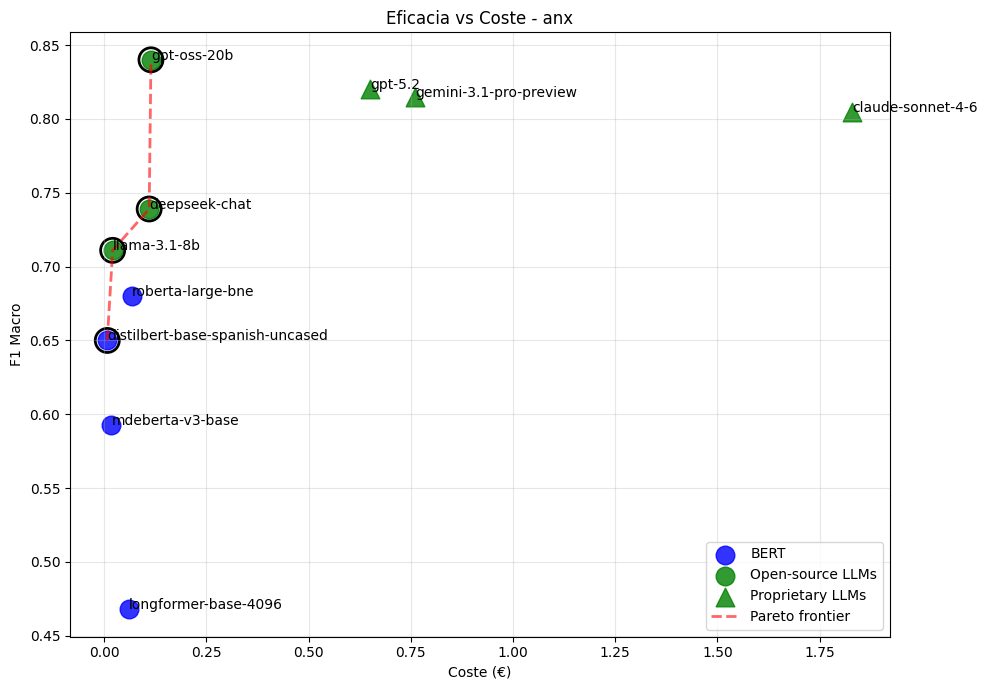

In [ ]:
plot_eficacia_coste(metricas_anx, "anx")

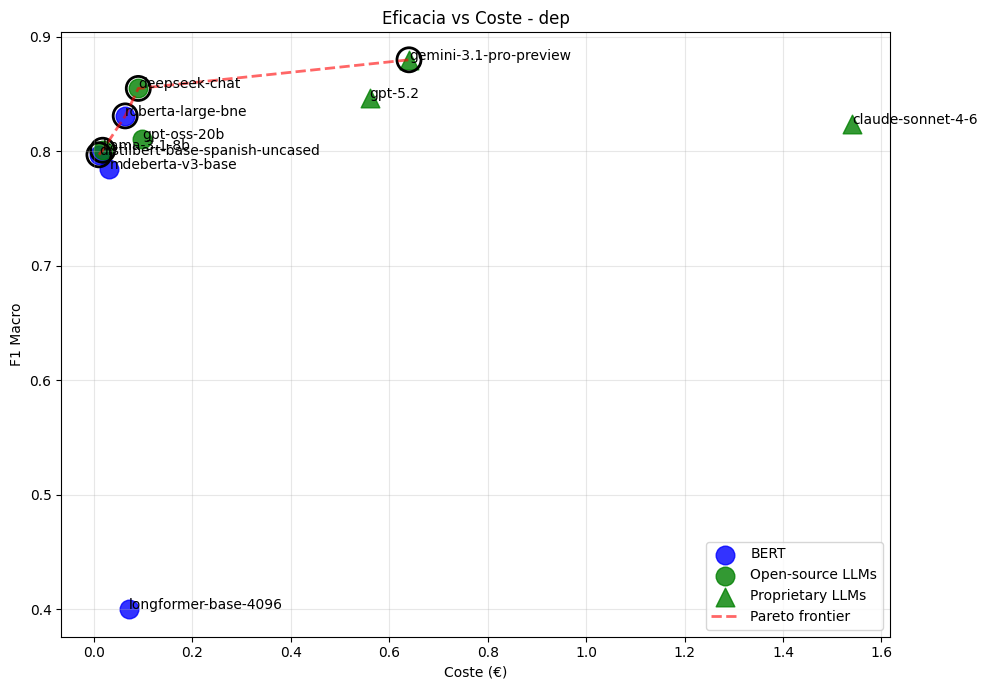

In [ ]:
plot_eficacia_coste(metricas_dep, "dep")

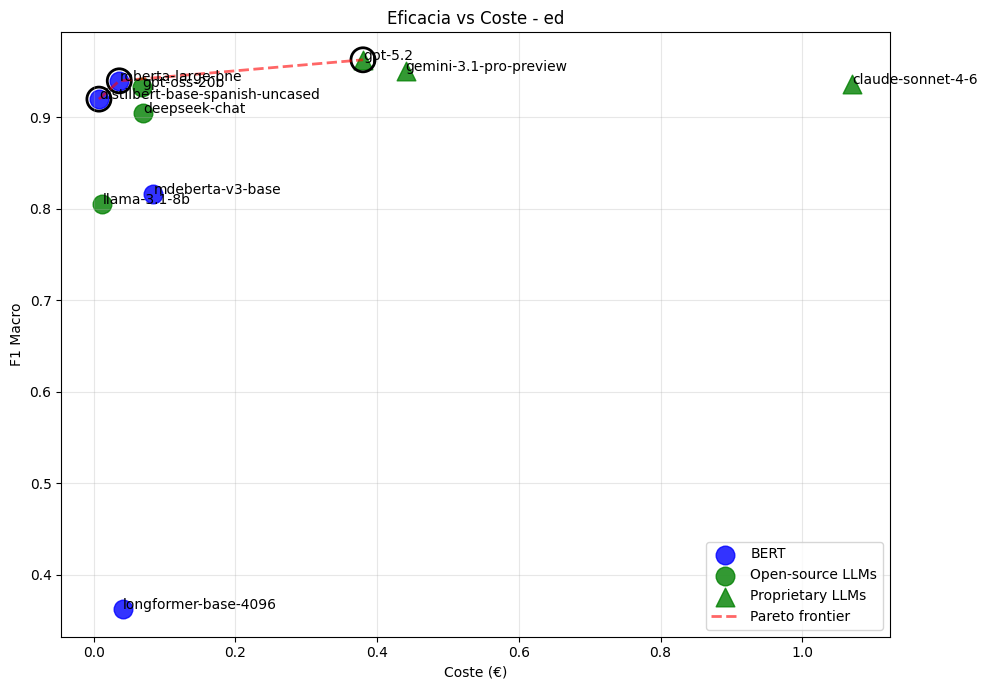

In [ ]:
plot_eficacia_coste(metricas_ed, "ed")

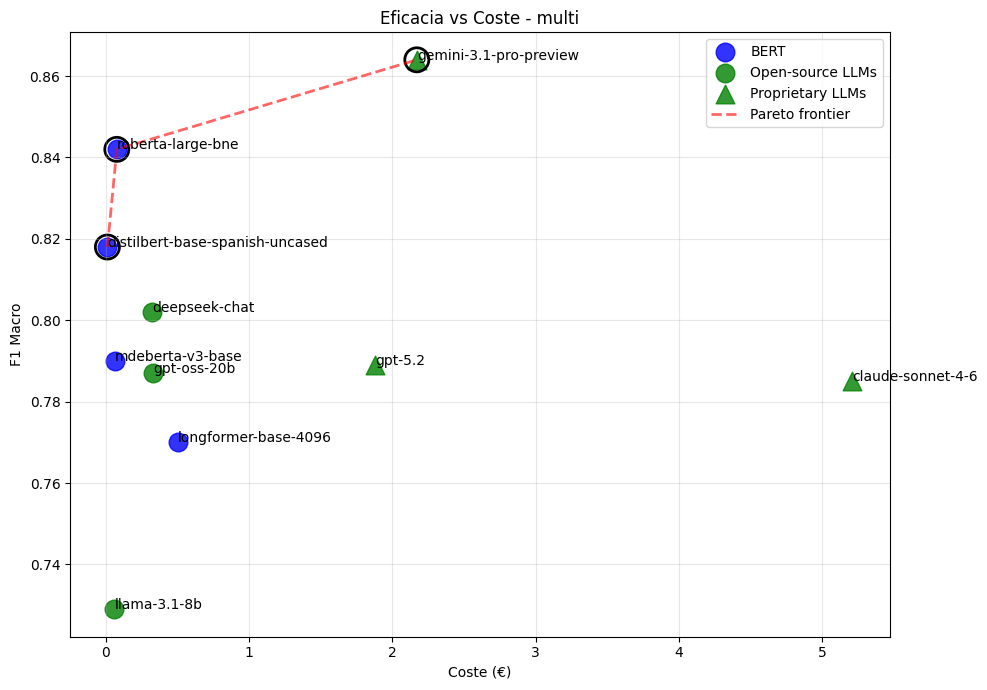

In [ ]:
plot_eficacia_coste(metricas_multi, "multi")